<a href="https://colab.research.google.com/github/shashikawka/Intelligent-Student-Performance-Analytics-and-Learning-Stratergy-Optimization/blob/main/step4_supervised_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 4 - Supervised Modeling
## Decision Tree | Random Forest | Linear Regression

| Task | Dataset | Models | Target |
|------|---------|--------|--------|
| Classification | UCI | Decision Tree + Random Forest | pass/fail (0/1) |
| Classification | xAPI | Decision Tree + Random Forest | Low/Med/High (0/1/2) |
| Regression | UCI | Linear Regression | G3 grade (1-20) |

---
## Section 1 - Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report, mean_squared_error,
    mean_absolute_error, r2_score
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#EF9F27'
GRAY   = '#888780'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False


---
## Section 2 - Load All Preprocessed Data

In [ ]:
# ── UCI Classification splits ────────────────────────────────────────────────
X_train_uci_clf = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_uci_clf.csv')
X_test_uci_clf  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_uci_clf.csv')
y_train_uci_clf = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_uci_clf.csv').squeeze()
y_test_uci_clf  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_uci_clf.csv').squeeze()

# ── UCI Regression splits ─────────────────────────────────────────────────────
X_train_uci_reg = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_uci_reg.csv')
X_test_uci_reg  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_uci_reg.csv')
y_train_uci_reg = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_uci_reg.csv').squeeze()
y_test_uci_reg  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_uci_reg.csv').squeeze()

# ── xAPI Classification splits ────────────────────────────────────────────────
X_train_xapi = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_xapi.csv')
X_test_xapi  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_xapi.csv')
y_train_xapi = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_xapi.csv').squeeze()
y_test_xapi  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_xapi.csv').squeeze()

print('UCI  Classification -> train:', X_train_uci_clf.shape, '| test:', X_test_uci_clf.shape)
print('UCI  Regression     -> train:', X_train_uci_reg.shape, '| test:', X_test_uci_reg.shape)
print('xAPI Classification -> train:', X_train_xapi.shape,    '| test:', X_test_xapi.shape)
print()
print('UCI  clf target distribution:', y_train_uci_clf.value_counts().to_dict(), '(0=Fail, 1=Pass)')
print('xAPI clf target distribution:', y_train_xapi.value_counts().to_dict(),    '(0=Low, 1=Med, 2=High)')
print('UCI  reg target  -> mean G3:', round(y_train_uci_reg.mean(), 2), '| min:', y_train_uci_reg.min(), '| max:', y_train_uci_reg.max())

UCI  Classification -> train: (835, 44) | test: (209, 44)
UCI  Regression     -> train: (792, 44) | test: (199, 44)
xAPI Classification -> train: (384, 27) | test: (96, 27)

UCI  clf target distribution: {1: 651, 0: 184} (0=Fail, 1=Pass)
xAPI clf target distribution: {1: 169, 2: 114, 0: 101} (0=Low, 1=Med, 2=High)
UCI  reg target  -> mean G3: 12.0 | min: 1 | max: 20


---
## Section 3 - Helper Functions

Two helper functions — one for classification, one for regression.
Written once, reused for every model.

In [ ]:
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te,
                        name, dataset, multi_class=False):
    """
    Trains a classifier and returns evaluation metrics.
    Works for binary (pass/fail) and multi-class (Low/Med/High).

    Metrics returned:
    - Accuracy  : % of correct predictions
    - F1-score  : balance of precision and recall
                  (better than accuracy when classes are imbalanced)
    - AUC       : Area Under ROC Curve (1.0 = perfect, 0.5 = random)
    - CV score  : 5-fold cross validation accuracy (checks stability)
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)

    acc  = accuracy_score(y_te, y_pred)
    avg  = 'macro' if multi_class else 'binary'
    f1   = f1_score(y_te, y_pred, average=avg)
    auc  = (roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
            if multi_class else roc_auc_score(y_te, y_prob[:, 1]))
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f'  [{dataset}] {name}')
    print(f'    Accuracy  : {acc*100:.2f}%')
    print(f'    F1 Score  : {f1*100:.2f}%')
    print(f'    AUC       : {auc:.4f}')
    print(f'    CV 5-fold : {cv.mean()*100:.2f}% +/- {cv.std()*100:.2f}%')
    print()

    return {'name': name, 'dataset': dataset,
            'accuracy': round(acc*100, 2), 'f1': round(f1*100, 2),
            'auc': round(auc, 4), 'cv_mean': round(cv.mean()*100, 2),
            'cv_std': round(cv.std()*100, 2),
            'y_pred': y_pred, 'y_prob': y_prob, 'model': model}


def evaluate_regressor(model, X_tr, X_te, y_tr, y_te, name, dataset):
    """
    Trains a regressor and returns evaluation metrics.

    Metrics returned:
    - RMSE : Root Mean Squared Error
             Average gap between predicted grade and actual grade
             Lower is better. RMSE of 2 means predictions are
             on average 2 grade points away from the truth.
    - MAE  : Mean Absolute Error — similar to RMSE but less sensitive
             to large errors
    - R2   : How much variance the model explains (1.0 = perfect,
             0 = model learned nothing, negative = worse than mean)
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    print(f'  [{dataset}] {name}')
    print(f'    RMSE : {rmse:.4f}  (avg grade error in points)')
    print(f'    MAE  : {mae:.4f}')
    print(f'    R2   : {r2:.4f}  (1.0 = perfect, 0 = learned nothing)')
    print()

    return {'name': name, 'dataset': dataset,
            'rmse': round(rmse, 4), 'mae': round(mae, 4),
            'r2': round(r2, 4), 'y_pred': y_pred, 'model': model}

---
## Section 4 - UCI Classification: Predict Pass / Fail

**Decision Tree** — simple, interpretable, produces a visual tree.
We limit depth to 5 to prevent overfitting (memorising training data).

**Random Forest** — 100 trees combined by majority vote.
More accurate than a single tree. Shows feature importance.

In [ ]:
print('=== UCI CLASSIFICATION ===')
print()

# Decision Tree
# max_depth=5: tree cannot grow too deep, prevents overfitting
dt_uci = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_uci_res = evaluate_classifier(
    dt_uci, X_train_uci_clf, X_test_uci_clf,
    y_train_uci_clf, y_test_uci_clf,
    'Decision Tree', 'UCI')

# Random Forest
# n_estimators=100: build 100 trees
# max_depth=10: each tree can be slightly deeper than single DT
rf_uci = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_uci_res = evaluate_classifier(
    rf_uci, X_train_uci_clf, X_test_uci_clf,
    y_train_uci_clf, y_test_uci_clf,
    'Random Forest', 'UCI')

=== UCI CLASSIFICATION ===

  [UCI] Decision Tree
    Accuracy  : 92.82%
    F1 Score  : 95.47%
    AUC       : 0.9044
    CV 5-fold : 89.10% +/- 0.70%

  [UCI] Random Forest
    Accuracy  : 89.95%
    F1 Score  : 93.62%
    AUC       : 0.9451
    CV 5-fold : 91.74% +/- 2.05%



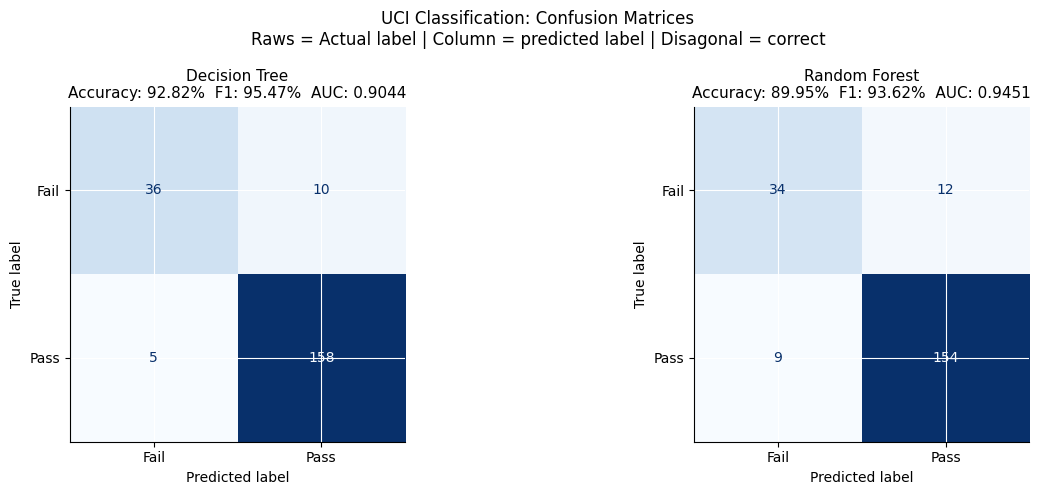

In [ ]:
# Figure 1: UCI Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('UCI Classification: Confusion Matrices\n'
              'Raws = Actual label | Column = predicted label | Disagonal = correct')

for ax, res, color in zip(axes,
        [dt_uci_res, rf_uci_res], [PURPLE, TEAL]):
    cm   = confusion_matrix(y_test_uci_clf, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        res['name'] + '\n'
        'Accuracy: ' + str(res['accuracy']) + '%  '
        'F1: ' + str(res['f1']) + '%  '
        'AUC: ' + str(res['auc']),
        fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig1_uci_clf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

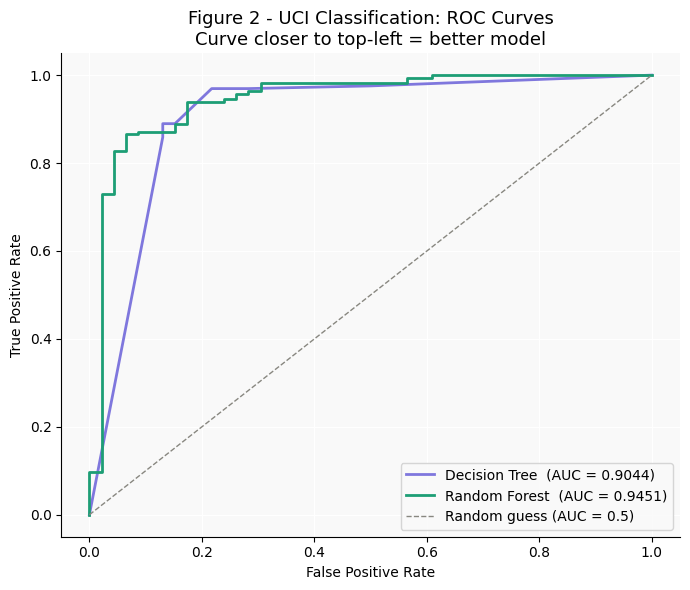

In [ ]:
# Figure 2: UCI ROC Curves
# ROC curve: x=false positive rate, y=true positive rate
# A model that randomly guesses follows the diagonal line
# A good model curves toward the top-left corner
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Figure 2 - UCI Classification: ROC Curves\n'
             'Curve closer to top-left = better model',
             fontsize=13 )

for res, color in zip([dt_uci_res, rf_uci_res], [PURPLE, TEAL]):
    fpr, tpr, _ = roc_curve(y_test_uci_clf, res['y_prob'][:, 1])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=res['name'] + '  (AUC = ' + str(res['auc']) + ')')

ax.plot([0,1],[0,1], color=GRAY, linestyle='--',
        linewidth=1, label='Random guess (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig2_uci_clf_roc.png', dpi=150, bbox_inches='tight')
plt.show()

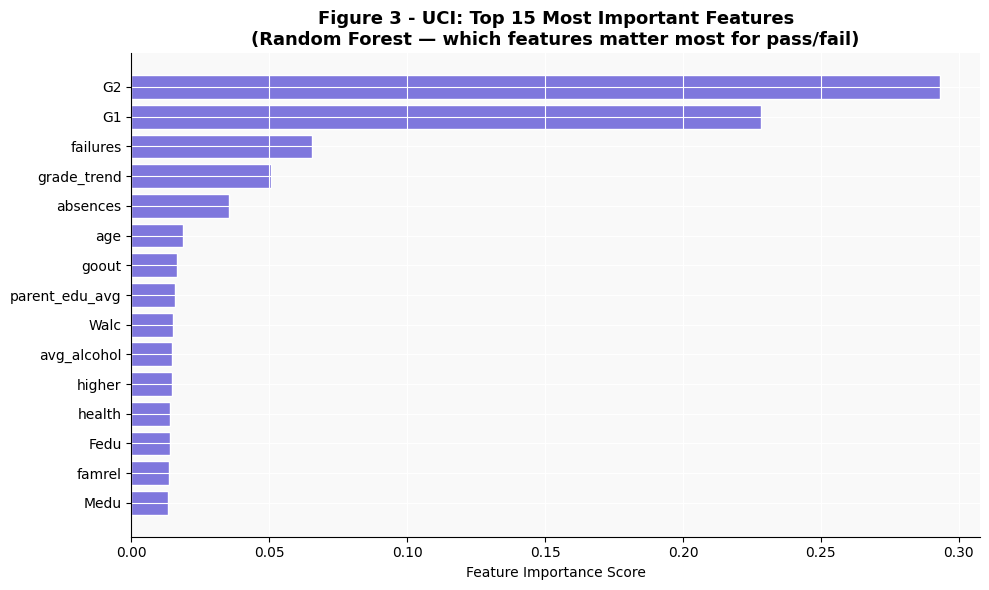


Top 5 features for predicting pass/fail:
  G2                        0.2930
  G1                        0.2282
  failures                  0.0656
  grade_trend               0.0506
  absences                  0.0353


In [ ]:
# Figure 3: UCI Feature Importance (Random Forest)
# Feature importance shows which features the model relied on most
# Higher bar = more important for predicting pass/fail
importances = pd.Series(
    rf_uci.feature_importances_,
    index=X_train_uci_clf.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=PURPLE, edgecolor='white')
ax.set_title('Figure 3 - UCI: Top 15 Most Important Features\n'
             '(Random Forest — which features matter most for pass/fail)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig3_uci_clf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Top 5 features for predicting pass/fail:')
for feat, score in importances.head(5).items():
    print(f'  {feat:<25} {score:.4f}')

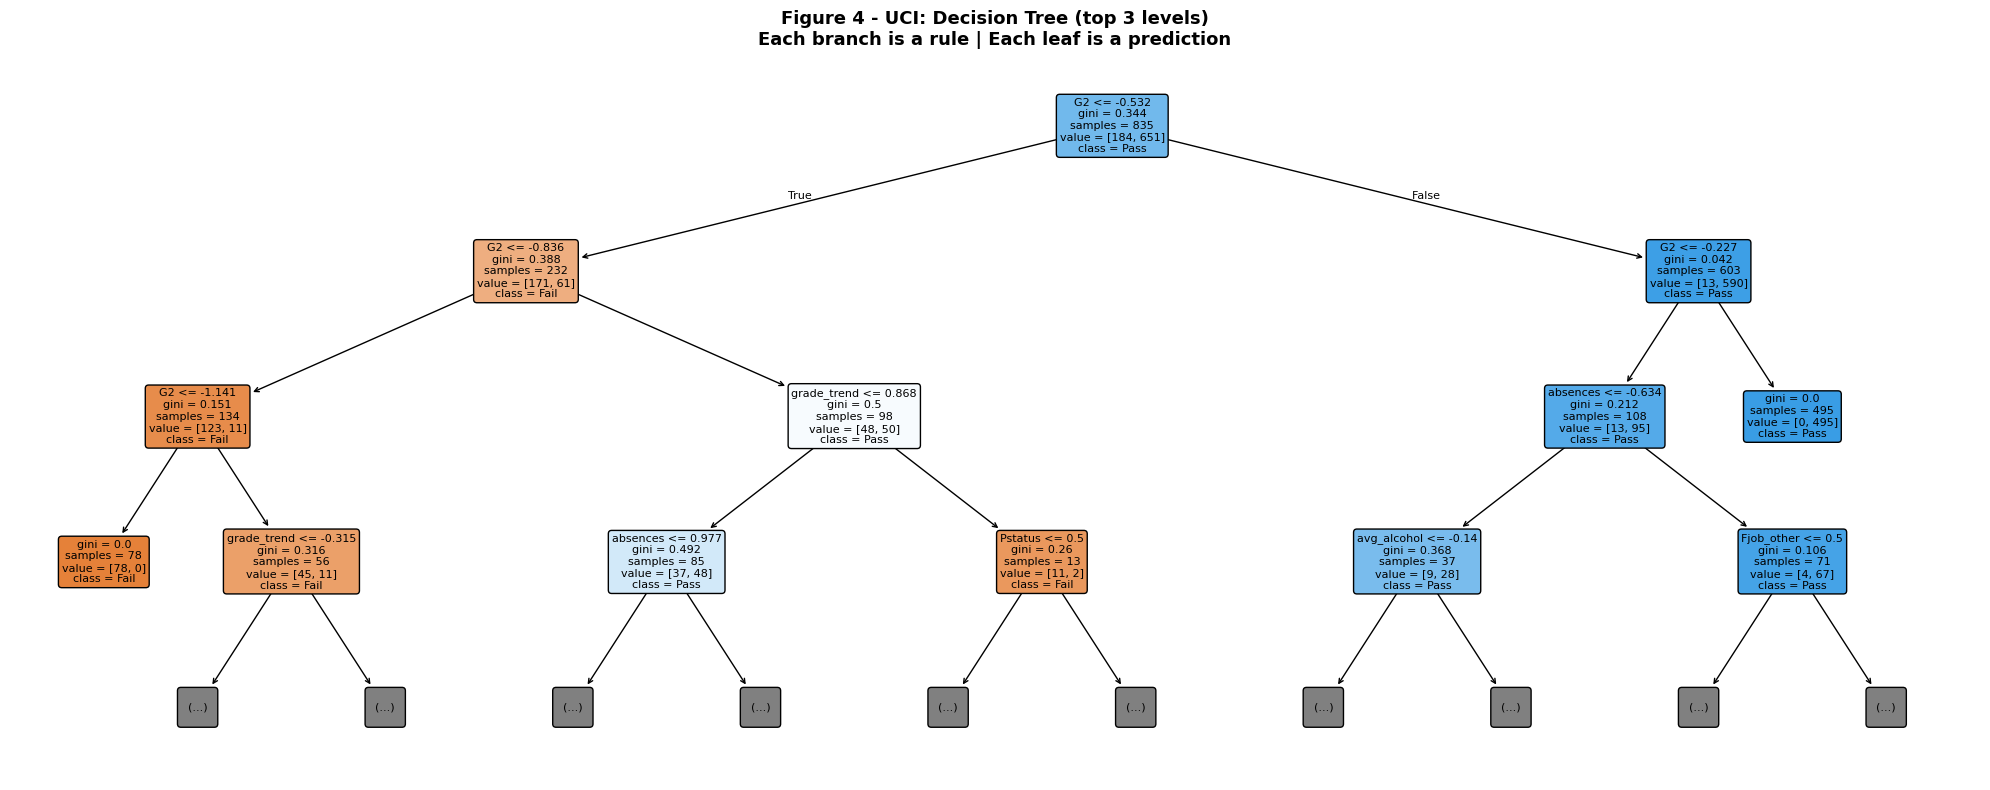

In [ ]:
# Figure 4: UCI Decision Tree Visualisation
# This is the key advantage of Decision Tree over Random Forest
# An educator can follow the branches and understand the logic
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_uci,
    feature_names=X_train_uci_clf.columns.tolist(),
    class_names=['Fail', 'Pass'],
    filled=True, rounded=True,
    fontsize=8, ax=ax,
    max_depth=3  # Show top 3 levels for readability
)
ax.set_title('Figure 4 - UCI: Decision Tree (top 3 levels)\n'
             'Each branch is a rule | Each leaf is a prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig4_uci_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 - xAPI Classification: Predict Low / Medium / High

Same two models applied to xAPI.
This is a **multi-class** problem (3 classes instead of 2).
F1-score uses macro average — treats all 3 classes equally.

In [ ]:
print('=== xAPI CLASSIFICATION ===')
print()

# Decision Tree on xAPI
dt_xapi = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_xapi_res = evaluate_classifier(
    dt_xapi, X_train_xapi, X_test_xapi,
    y_train_xapi, y_test_xapi,
    'Decision Tree', 'xAPI', multi_class=True)

# Random Forest on xAPI
rf_xapi = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_xapi_res = evaluate_classifier(
    rf_xapi, X_train_xapi, X_test_xapi,
    y_train_xapi, y_test_xapi,
    'Random Forest', 'xAPI', multi_class=True)

=== xAPI CLASSIFICATION ===

  [xAPI] Decision Tree
    Accuracy  : 82.29%
    F1 Score  : 82.49%
    AUC       : 0.9165
    CV 5-fold : 65.63% +/- 3.66%

  [xAPI] Random Forest
    Accuracy  : 80.21%
    F1 Score  : 80.52%
    AUC       : 0.9403
    CV 5-fold : 77.60% +/- 1.27%



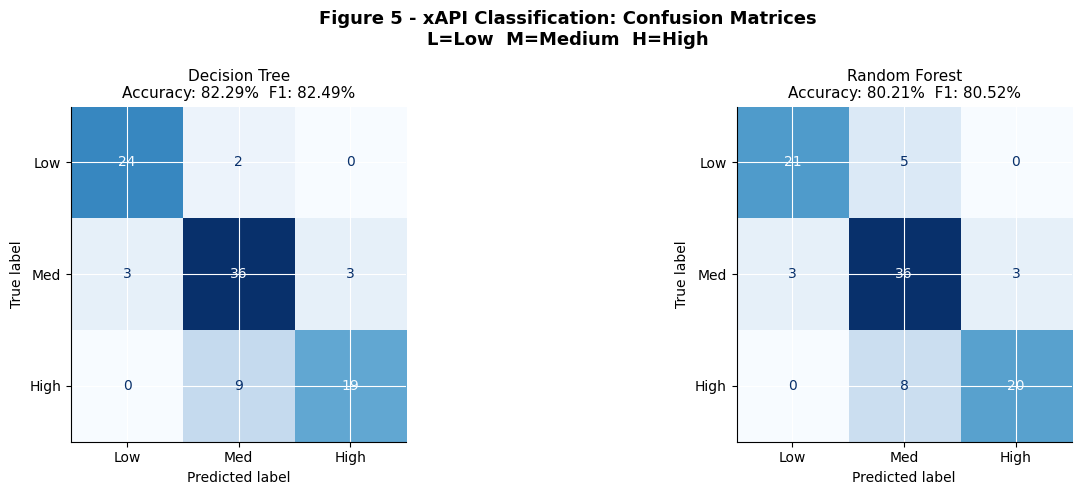

In [ ]:
# Figure 5: xAPI Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5 - xAPI Classification: Confusion Matrices\n'
             'L=Low  M=Medium  H=High',
             fontsize=13, fontweight='bold')

for ax, res in zip(axes, [dt_xapi_res, rf_xapi_res]):
    cm   = confusion_matrix(y_test_xapi, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Med', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        res['name'] + '\n'
        'Accuracy: ' + str(res['accuracy']) + '%  '
        'F1: ' + str(res['f1']) + '%',
        fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig5_xapi_clf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

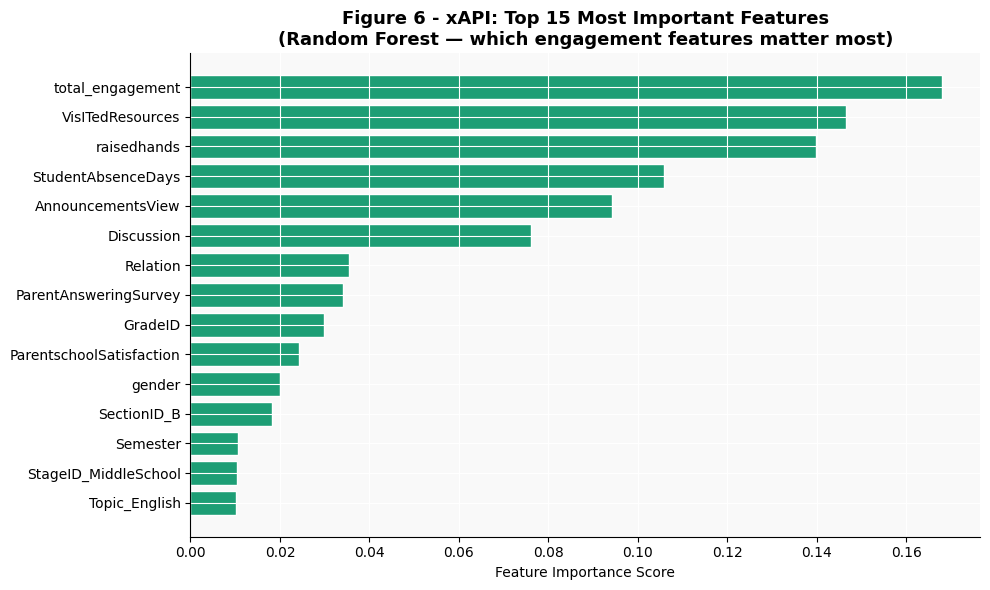


Top 5 features for predicting performance class:
  total_engagement             0.1681
  VisITedResources             0.1466
  raisedhands                  0.1398
  StudentAbsenceDays           0.1059
  AnnouncementsView            0.0942


In [ ]:
# Figure 6: xAPI Feature Importance (Random Forest)
importances_xapi = pd.Series(
    rf_xapi.feature_importances_,
    index=X_train_xapi.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances_xapi.index[::-1], importances_xapi.values[::-1],
        color=TEAL, edgecolor='white')
ax.set_title('Figure 6 - xAPI: Top 15 Most Important Features\n'
             '(Random Forest — which engagement features matter most)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig6_xapi_clf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Top 5 features for predicting performance class:')
for feat, score in importances_xapi.head(5).items():
    print(f'  {feat:<28} {score:.4f}')

---
## Section 6 - UCI Regression: Predict G3 Grade

**Linear Regression** finds the best straight-line relationship
between the features and the G3 grade.

Unlike classification, the output is a **number** (predicted grade 1-20),
so we measure how close the predictions are to the real grades.

**Note:** G3=0 (withdrawal) rows were removed from this task only.
The model predicts grades for students who sat the exam.

In [ ]:
print('=== UCI REGRESSION ===')
print()

# Linear Regression
# Fits a linear equation: G3 = w1*G1 + w2*G2 + w3*absences + ...
# Each coefficient tells us how much each feature affects the grade
lr_uci = LinearRegression()
lr_uci_res = evaluate_regressor(
    lr_uci,
    X_train_uci_reg, X_test_uci_reg,
    y_train_uci_reg, y_test_uci_reg,
    'Linear Regression', 'UCI')

=== UCI REGRESSION ===

  [UCI] Linear Regression
    RMSE : 0.8830  (avg grade error in points)
    MAE  : 0.7077
    R2   : 0.9068  (1.0 = perfect, 0 = learned nothing)



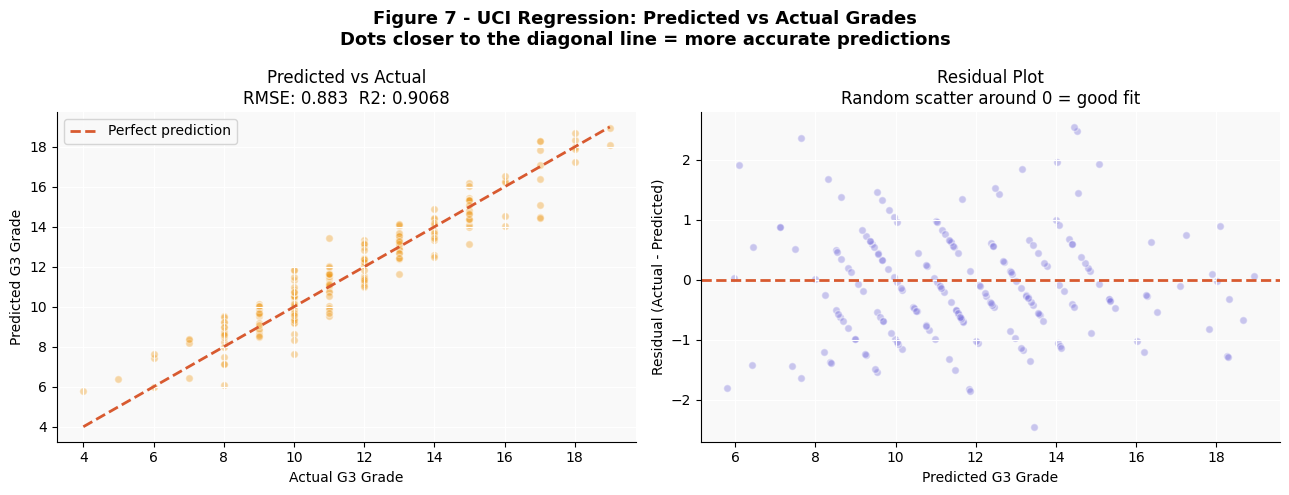

In [ ]:
# Figure 7: Predicted vs Actual Grades
# A perfect model would have all dots on the diagonal line
# Dots spread around the line show prediction error
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7 - UCI Regression: Predicted vs Actual Grades\n'
             'Dots closer to the diagonal line = more accurate predictions',
             fontsize=13, fontweight='bold')

y_pred_lr = lr_uci_res['y_pred']

# Scatter: predicted vs actual
axes[0].scatter(y_test_uci_reg, y_pred_lr,
                alpha=0.4, color=AMBER, s=30, edgecolors='white')
min_val = min(y_test_uci_reg.min(), y_pred_lr.min())
max_val = max(y_test_uci_reg.max(), y_pred_lr.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color=CORAL, linewidth=2, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual G3 Grade')
axes[0].set_ylabel('Predicted G3 Grade')
axes[0].set_title(
    'Predicted vs Actual\n'
    'RMSE: ' + str(lr_uci_res['rmse']) + '  R2: ' + str(lr_uci_res['r2']))
axes[0].legend()

# Residual plot: predicted vs error
residuals = y_test_uci_reg.values - y_pred_lr
axes[1].scatter(y_pred_lr, residuals,
                alpha=0.4, color=PURPLE, s=30, edgecolors='white')
axes[1].axhline(0, color=CORAL, linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted G3 Grade')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot\nRandom scatter around 0 = good fit')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig7_uci_regression.png', dpi=150, bbox_inches='tight')
plt.show()

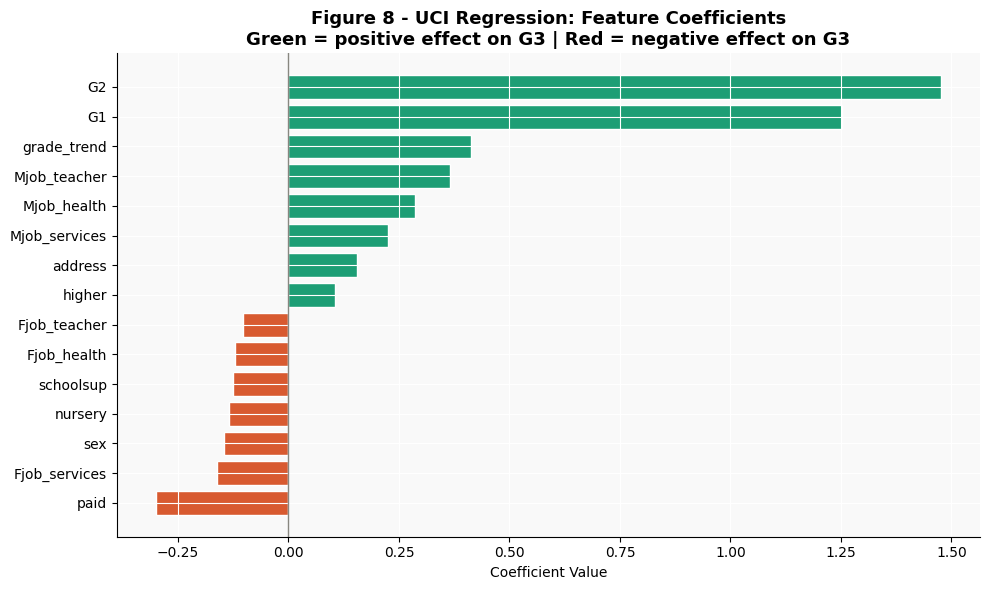


Top 5 positive features (help the grade):
  G2                        +1.4759
  G1                        +1.2515
  grade_trend               +0.4127
  Mjob_teacher              +0.3662
  Mjob_health               +0.2863
Top 5 negative features (hurt the grade):
  paid                      -0.2995
  Fjob_services             -0.1627
  sex                       -0.1465
  nursery                   -0.1353
  schoolsup                 -0.1252


In [ ]:
# Figure 8: Top regression coefficients
# Coefficient = how much G3 changes when that feature increases by 1
# Positive = feature helps the grade
# Negative = feature hurts the grade
coef = pd.Series(lr_uci.coef_, index=X_train_uci_reg.columns)
coef_top = coef.abs().sort_values(ascending=False).head(15)
coef_plot = coef[coef_top.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TEAL if v > 0 else CORAL for v in coef_plot.values]
ax.barh(coef_plot.index, coef_plot.values, color=colors, edgecolor='white')
ax.axvline(0, color=GRAY, linewidth=1)
ax.set_title('Figure 8 - UCI Regression: Feature Coefficients\n'
             'Green = positive effect on G3 | Red = negative effect on G3',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig8_uci_regression_coef.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Top 5 positive features (help the grade):')
for f, v in coef.sort_values(ascending=False).head(5).items():
    print(f'  {f:<25} +{v:.4f}')
print('Top 5 negative features (hurt the grade):')
for f, v in coef.sort_values().head(5).items():
    print(f'  {f:<25} {v:.4f}')

---
## Section 7 - Model Comparison

Compare all models side by side across both datasets.

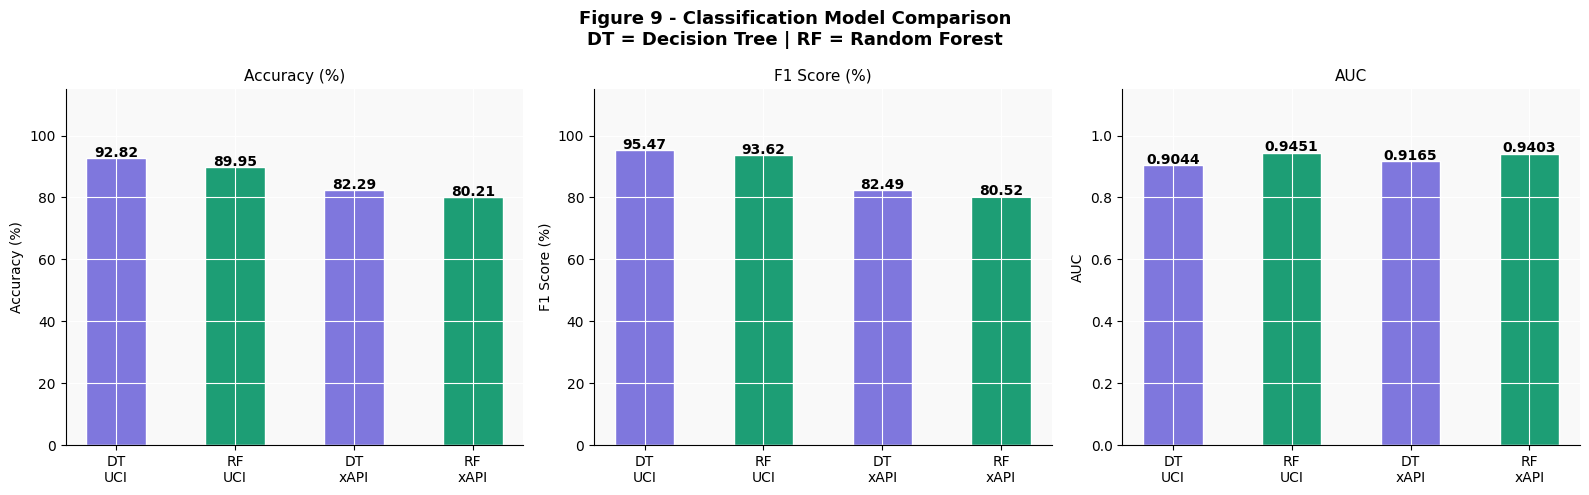

In [ ]:
# Figure 9: Classification model comparison bar chart
results_clf = [dt_uci_res, rf_uci_res, dt_xapi_res, rf_xapi_res]
labels_clf  = ['DT\nUCI', 'RF\nUCI', 'DT\nxAPI', 'RF\nxAPI']
colors_clf  = [PURPLE, TEAL, PURPLE, TEAL]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 9 - Classification Model Comparison\n'
             'DT = Decision Tree | RF = Random Forest',
             fontsize=13, fontweight='bold')

metrics = ['accuracy', 'f1', 'auc']
titles  = ['Accuracy (%)', 'F1 Score (%)', 'AUC']
scales  = [100, 100, 1]

for ax, metric, title, scale in zip(axes, metrics, titles, scales):
    vals = [r[metric] for r in results_clf]
    bars = ax.bar(labels_clf, vals, color=colors_clf, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.3 if scale == 100 else 0.005),
                str(val), ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(title)
    ax.set_ylim(0, scale * 1.15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 - Results Summary

Print all results — copy into your report.

In [ ]:
print('=' * 62)
print('MODELING RESULTS SUMMARY')
print('=' * 62)

print()
print('CLASSIFICATION RESULTS')
print('-' * 62)
print(f'{"Model":<22} {"Dataset":<8} {"Accuracy":>10} {"F1":>8} {"AUC":>8} {"CV":>12}')
print('-' * 62)
for r in [dt_uci_res, rf_uci_res, dt_xapi_res, rf_xapi_res]:
    cv_str = str(r['cv_mean']) + '% +/-' + str(r['cv_std']) + '%'
    print(f'{r["name"]:<22} {r["dataset"]:<8} {str(r["accuracy"]) + "%":>10} '
          f'{str(r["f1"]) + "%":>8} {str(r["auc"]):>8} {cv_str:>12}')

print()
print('REGRESSION RESULTS')
print('-' * 62)
print(f'{"Model":<22} {"Dataset":<8} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 62)
print(f'{lr_uci_res["name"]:<22} {lr_uci_res["dataset"]:<8} '
      f'{lr_uci_res["rmse"]:>8} {lr_uci_res["mae"]:>8} {lr_uci_res["r2"]:>8}')

print()
print('KEY FINDINGS')
print('-' * 62)
# Best classifier on each dataset
best_uci  = max([dt_uci_res,  rf_uci_res],  key=lambda x: x['accuracy'])
best_xapi = max([dt_xapi_res, rf_xapi_res], key=lambda x: x['accuracy'])
print(f'Best classifier on UCI  : {best_uci["name"]}  '
      f'(Accuracy: {best_uci["accuracy"]}%  AUC: {best_uci["auc"]})')
print(f'Best classifier on xAPI : {best_xapi["name"]}  '
      f'(Accuracy: {best_xapi["accuracy"]}%  AUC: {best_xapi["auc"]})')
print(f'Regression (Linear Reg) : RMSE={lr_uci_res["rmse"]}  R2={lr_uci_res["r2"]}')
r2_interp = ('strong' if lr_uci_res['r2'] > 0.7
             else 'moderate' if lr_uci_res['r2'] > 0.4 else 'weak')
print(f'R2 interpretation       : {r2_interp} fit')
print()
print('=' * 62)
print('Modeling complete! Ready for Step 5 - Unsupervised.')
print('=' * 62)

MODELING RESULTS SUMMARY

CLASSIFICATION RESULTS
--------------------------------------------------------------
Model                  Dataset    Accuracy       F1      AUC           CV
--------------------------------------------------------------
Decision Tree          UCI          92.82%   95.47%   0.9044 89.1% +/-0.7%
Random Forest          UCI          89.95%   93.62%   0.9451 91.74% +/-2.05%
Decision Tree          xAPI         82.29%   82.49%   0.9165 65.63% +/-3.66%
Random Forest          xAPI         80.21%   80.52%   0.9403 77.6% +/-1.27%

REGRESSION RESULTS
--------------------------------------------------------------
Model                  Dataset      RMSE      MAE       R2
--------------------------------------------------------------
Linear Regression      UCI         0.883   0.7077   0.9068

KEY FINDINGS
--------------------------------------------------------------
Best classifier on UCI  : Decision Tree  (Accuracy: 92.82%  AUC: 0.9044)
Best classifier on xAPI : Decisi